# 03 - Data enrichment and separation 

this notebook serves as a the third step before the actual analysis, it enriches the data with supplemental data necessary for subsequent evaluation of the data. It includes brief summary statistics and evaluation of the enriched data. it also creates subsets for data that will then be used for the analysis as in the previous notebook, we assessed, that data with few years of records will not be able to show any growth dynamics if sufficient data is lacking. 

in general we will focus on two dataset compositions: 

1. dataset containing the current year regardless of the number of years of data provided 
2. dataset containing a subset of firm with a threshold amount of number of years 
    - this data will be more important to conduct research on growth dynamics. 


the first part will enrich the data with necessary columns, later on the split of above two cases will be performed and saved as separate pickle files for later use     

the split in this fashion was inspired by the use of llm [AI-9]


some results: 

- share of ai firms increased over the years (given ai firms classified as employing at least one AI-related employee)

In [176]:
# this file is used to find the project root and set the working directory to it.
from pathlib import Path
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 

In [177]:
def find_project_root(marker=".project-root"):
    path = Path.cwd().resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
print(f"Project root found at: {PROJECT_ROOT}")

cwd = PROJECT_ROOT

Project root found at: /Users/ducjeremyvu/mime/sem-1/files/bank-fintech/essay


In [178]:
# basis for this is the cleaned data from notebook 01 
data = pd.read_pickle(cwd / "data/babina_cleaned.pkl")

data.head(3).T.head()

,0,1,2
gvkey,1004,1004,1004
year,2005,2006,2007
aiempl,0,0,0
totalempl,2966,3114,3270
act,3266.840875,3378.999124,7580.053949


# AI Classifier

for simplicity reasons, we will first employ a simple classification, whether firms are AI firms or not. Formally we say that if a firm employs at least 1 AI related employee we classify it as a an AI Firm, while the rest remain non-AI firms. 

for the whole dataset we see that firms being non ai dominate the whole dataset. looking at only the earlierst year of the dataset, 2005, we can see that only roughly 20% of firms had ai related employment. however over the years, we can see a gradual increase, looking at the most recent year, that is 2018, we can see that its fairly even between ai and non ai firms. we can only assume that the percentage of ai employments keeps on increasing since after 2018, technological advancement on ai was even more pronounced after. 

In [179]:
# classifying ai companies 
data['aiemp_gt_0'] = data['aiempl'] > 0

# comparing ai firms vs non ai firms for each year 
(
    data.groupby('year')['aiemp_gt_0']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

aiemp_gt_0,False,True
year,,
2005,0.817994,0.182006
2006,0.795127,0.204873
2007,0.769765,0.230235
2008,0.745965,0.254035
2009,0.725529,0.274471
2010,0.713277,0.286723
2011,0.698103,0.301897
2012,0.669367,0.330633
2013,0.634967,0.365033


# AI Employment to Total Employment ratio 

The dataset conveniently supplies the dataset with number of ai employment and total employment values. With these numbers, we can construct and ai ratio that is simply the ratio of ai employment to total employment.

however we can see that ai employment ratio overall is rather tiny, median accounts 0.02 so we conclude that above classification may be a simpler indicator for ai firms or non ai firms. but we keep that metric, because it might be helpful for other types fo analyses

In [180]:
# construct a ratio for ai employment to total employment
data['aiempl_ratio'] = data['aiempl']/data['totalempl']

data[['year', 'aiempl', 'totalempl', 'aiempl_ratio']].describe()

,year,aiempl,totalempl,aiempl_ratio
count,50622.000000,50622.000000,5.062200e+04,50622.000000
mean,2011.316740,8.094386,6.576617e+03,0.000918
std,3.975979,97.511928,2.717678e+04,0.004329
min,2005.000000,0.000000,1.000000e+00,0.000000
25%,2008.000000,0.000000,2.360000e+02,0.000000
50%,2011.000000,0.000000,8.920000e+02,0.000000
75%,2015.000000,1.000000,3.227000e+03,0.000348
max,2018.000000,6190.000000,1.552543e+06,0.400000


# Enrichment to years 

in this section we enrich the data with number of years a firm provides information on, also the first and last years of data for each firm. the one enriched metric of interest is the number of years (n_years) as it will allow us to subset a selection of firms that provided at least a certain number of years for our growth analysis. 

In [181]:

## REF AI-6

data["n_years"] = (
    data.groupby("gvkey")["year"]
        .transform("count")
)

data["first_year"] = (
    data.groupby("gvkey")["year"]
        .transform("min")
)

data["last_year"] = (
    data.groupby("gvkey")["year"]
        .transform("max")
)

data[["gvkey", "year", "n_years", "first_year", "last_year"]].head(10)

,gvkey,year,n_years,first_year,last_year
0,1004,2005,13,2005,2017
1,1004,2006,13,2005,2017
2,1004,2007,13,2005,2017
3,1004,2008,13,2005,2017
4,1004,2009,13,2005,2017
5,1004,2010,13,2005,2017
6,1004,2011,13,2005,2017
7,1004,2012,13,2005,2017
8,1004,2013,13,2005,2017
9,1004,2014,13,2005,2017


# Market Capitalization 

given the data we can construct the market capitalization as the product of the number of outstanding shares and the stock price.
since we have both these information we can easily add another column to the dataset. 

the question here is which price to use, that depends on whether current data at hand coincides with fiscal year measures or year end closing price. we argue that metrics like these might be collected as part of end of fiscal year annual practices acommodating the annual reports. that makes sense, because the metrics supplied strongly reflect metrics from financial reports. 


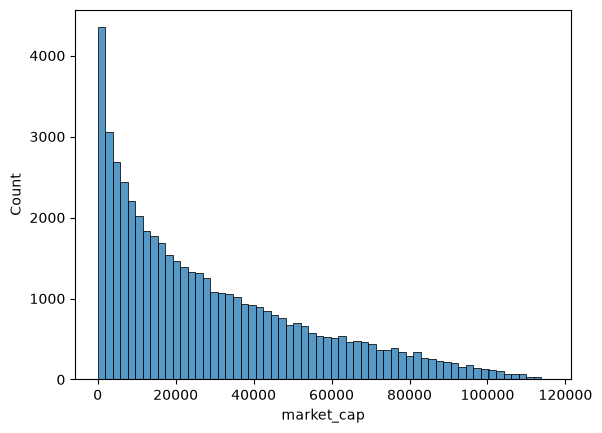

In [182]:
data["market_cap"] = data["csho"] * data["prcc_f"]

sns.histplot(data["market_cap"])
plt.show()

# Growth rates 

instead of just having tha metrics, growth rates normalize those values and might aid in better comparisons across firms with varying size. 

code for computing growth rates supplied by AI [AI-10]

### Revenue Growth Rate

In [183]:
data = data.sort_values(["gvkey", "year"])

data["revenue_growth"] = (
    data.groupby("gvkey")["revt"]
        .pct_change()
)

data[["gvkey", "year", "revt", "revenue_growth"]].head(20)

,gvkey,year,revt,revenue_growth
0,1004,2005,4796.981326,NaN
1,1004,2006,27194.094865,4.669002
2,1004,2007,8471.348654,-0.688486
3,1004,2008,26383.568475,2.114447
4,1004,2009,22451.083953,-0.149051
5,1004,2010,19117.488382,-0.148483
6,1004,2011,12855.922331,-0.327531
7,1004,2012,9963.884188,-0.224958
8,1004,2013,5185.777690,-0.479543
9,1004,2014,8518.906824,0.642744


In [184]:
data = data.copy()

data["log_revenue_growth"] = (
    data.groupby("gvkey")["revt"]
        .transform(lambda x: np.log(x).diff())
)

data['log_revenue_growth'].describe()

count    42769.000000
mean        -0.001482
std          1.401740
min         -9.471966
25%         -0.696554
50%         -0.002466
75%          0.684009
max          9.683645
Name: log_revenue_growth, dtype: float64

## employment growth

In [185]:
data["employment_growth"] = (
    data.groupby("gvkey")["totalempl"]
        .pct_change()
)

data[["gvkey", "year", "totalempl", "employment_growth"]].head(20)

,gvkey,year,totalempl,employment_growth
0,1004,2005,2966,NaN
1,1004,2006,3114,0.049899
2,1004,2007,3270,0.050096
3,1004,2008,3400,0.039755
4,1004,2009,3426,0.007647
5,1004,2010,3698,0.079393
6,1004,2011,3970,0.073553
7,1004,2012,4179,0.052645
8,1004,2013,4299,0.028715
9,1004,2014,4276,-0.005350


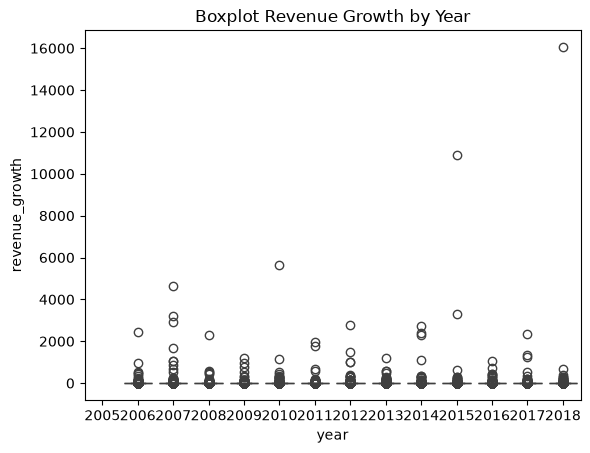

In [186]:
plot_box_rev_growth = sns.boxplot(x='year', y='revenue_growth', data=data)
plot_box_rev_growth.set_title('Boxplot Revenue Growth by Year')
plt.show()

# Financial Metrics [AI-12]

several basic financial metrics might aid in assessing whether ai firms substantially differ from non-ai firms or not. these are standard financial metrics used in financial analyes that are build on the standard financial data. 

which is why we will compute these for potential use later on

the following will be computed: 

Return on Assets
    measures



In [187]:
# return on assets ROA 

data["roa"] = data["ni"] / data["at"]

data['ni_over_totalempl'] = data['ni'] / data['totalempl']
# 


we can see firms having negative returns which is something we would expect but the max has a return of 2456 which is a 245600 % return which seems to be a bit odd 

In [188]:
data["roa"].describe()

count    50622.000000
mean         0.208662
std         11.860670
min        -19.073949
25%          0.009154
50%          0.026875
75%          0.055233
max       2456.927679
Name: roa, dtype: float64

In [189]:
data[["roa", 'gvkey']].sort_values(by="roa", ascending=False).head(10)

,roa,gvkey
44437,2456.927679,177376
1138,703.288681,2176
19854,396.456199,24430
50116,348.268214,266315
9731,335.285888,10839
26836,220.593163,61179
27674,211.123799,62072
18683,166.386063,22817
23406,147.155267,29011
37450,88.738614,145348


In [190]:
data[data['gvkey'] == 177376]

,gvkey,year,aiempl,totalempl,act,ap,apalch,aqc,at,bast,...,aiempl_ratio,n_years,first_year,last_year,market_cap,revenue_growth,log_revenue_growth,employment_growth,roa,ni_over_totalempl
44426,177376,2005,0,7271,9748.342984,11213.351442,289.474639,516.759800,26535.264698,643.582376,...,0.000000,14,2005,2018,12193.122059,NaN,NaN,NaN,0.022641,0.082626
44427,177376,2006,1,7647,2135.651952,2989.541246,5.799883,319.768272,3859.340314,492.495068,...,0.000131,14,2005,2018,107545.009936,-0.507166,-0.707583,0.051712,0.529542,0.267253
44428,177376,2007,2,7803,4265.794680,1779.608945,160.376188,694.505783,23355.238465,205.282994,...,0.000256,14,2005,2018,13508.213074,0.417127,0.348631,0.020400,0.025985,0.077776
44429,177376,2008,2,8008,8741.057667,9313.722292,297.516027,52.727923,45989.422169,511.913640,...,0.000250,14,2005,2018,43523.843026,-0.519831,-0.733616,0.026272,-0.003096,-0.017780
44430,177376,2009,6,7871,8009.076336,3118.403153,-92.138585,313.271843,35184.397911,1318.384271,...,0.000762,14,2005,2018,33326.345546,2.225391,1.171054,-0.017108,0.021598,0.096547
44431,177376,2010,6,8100,467.221851,7521.325278,-74.836820,392.487708,10855.267206,750.034962,...,0.000741,14,2005,2018,22495.375001,0.081285,0.078150,0.029094,0.015741,0.021095
44432,177376,2011,7,9074,10394.524756,8908.267767,375.906347,274.795218,64993.139517,1144.012226,...,0.000771,14,2005,2018,6834.116979,-0.792897,-1.574539,0.120247,0.014459,0.103563
44433,177376,2012,7,9894,4787.521551,11322.644849,13.797265,155.367990,44934.946843,50.624699,...,0.000707,14,2005,2018,15483.839753,1.477277,0.907160,0.090368,-0.002398,-0.010889
44434,177376,2013,10,10833,7302.191715,2962.637642,53.827473,580.694866,31573.343160,736.332530,...,0.000923,14,2005,2018,89463.157004,-0.175819,-0.193366,0.094906,0.062583,0.182400
44435,177376,2014,20,11490,4151.420050,6193.216602,342.989145,164.529713,5492.245030,1409.192491,...,0.001741,14,2005,2018,11091.438049,-0.308088,-0.368296,0.060648,0.187146,0.089456


In [191]:
data['ni_over_totalempl'].describe()

count    50622.000000
mean         6.778142
std         38.261310
min       -142.479392
25%          0.085365
50%          0.648391
75%          3.233194
max       2122.653912
Name: ni_over_totalempl, dtype: float64

/Users/ducjeremyvu/mime/sem-1/files/bank-fintech/essay/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='ni_over_totalempl', ylabel='Count'>

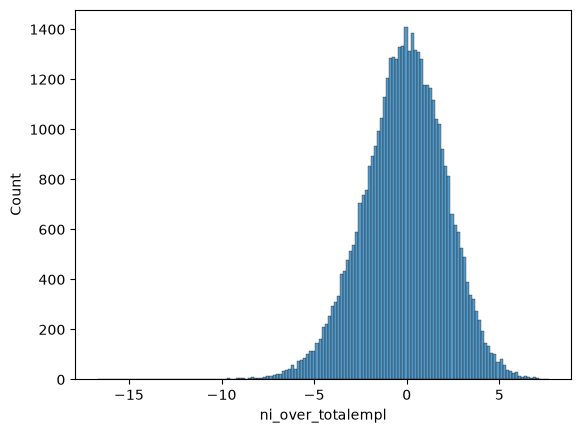

In [192]:
sns.histplot(np.log(data['ni_over_totalempl']))

# Log of metrics 

For data that has many large values and is heavily right-skewed, taking the logarithm of the values might reduce the influence of extreme observations and make the data easier to compare. For some metrics, logs are not necessary. For example, total revenue does not seem very skewed, so applying a log transformation would likely not add much value.


The first cell summarizes all actions performed for logarithmic scale, the later parts show reasons and justifications for doing so 

In [193]:
data['log_totalempl'] = data['totalempl'].apply(lambda x: np.log(x) if x > 0 else np.nan)
data['log_aiemplratio'] = data['aiempl_ratio'].apply(lambda x: np.log(x) if x > 0 else np.nan)
data['log_market_cap'] = data['market_cap'].apply(lambda x: np.log(x) if x > 0 else np.nan)

### Revenue

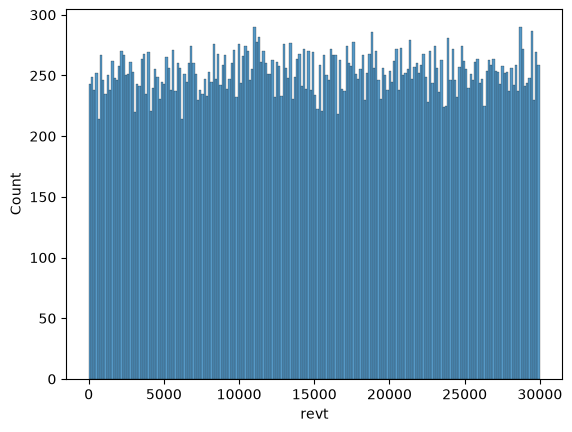

In [194]:
sns.histplot(data['revt'], bins=200)
plt.show()

<Axes: xlabel='revt', ylabel='Count'>

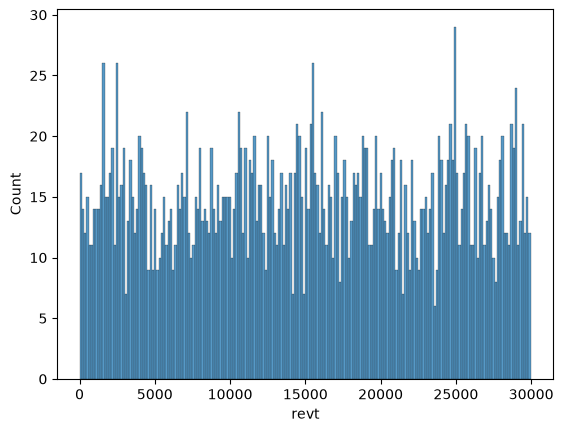

In [195]:
## subsetting dataset for only year 2018 
sns.histplot(data[data['year'] == 2018]['revt'], bins=200)


In [196]:
# REF [AI-13]
# this code was the result for testing on skewness of the data 

x = data.loc[data['year'] == 2018, 'revt']

print(x.describe())

print("Skew:", x.skew())

count     2979.000000
mean     15064.775182
std       8652.441380
min         12.279759
25%       7719.730039
50%      15161.834083
75%      22674.780227
max      29964.383637
Name: revt, dtype: float64
Skew: -0.013421918675155554


### total employment 

for total employment we can see that a log conversion leads to a more normal distribution of the data. 

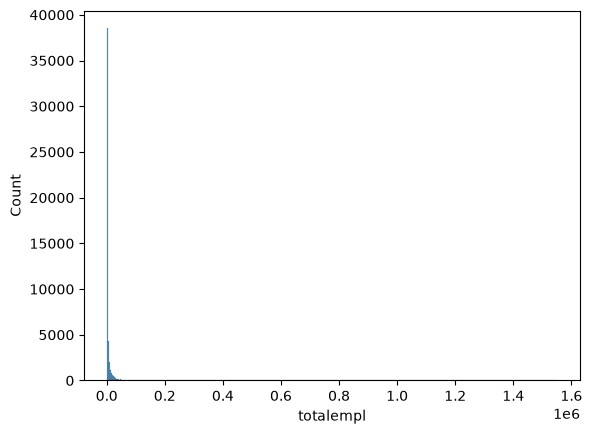

In [197]:
sns.histplot(data['totalempl'])
plt.show()

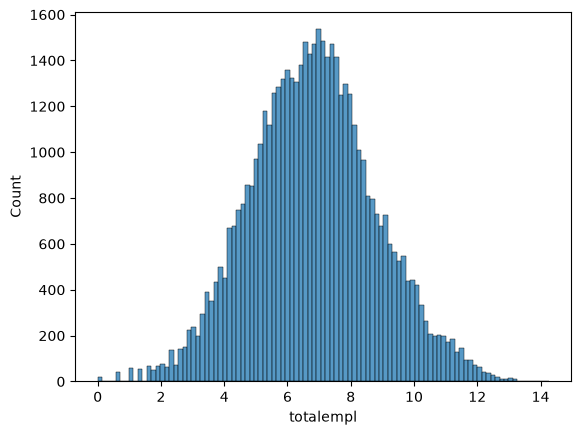

In [198]:
sns.histplot(np.log(data['totalempl']))
plt.show()

In [199]:
data[data['totalempl'] == data['totalempl'].max()]

,gvkey,year,aiempl,totalempl,act,ap,apalch,aqc,at,bast,...,last_year,market_cap,revenue_growth,log_revenue_growth,employment_growth,roa,ni_over_totalempl,log_totalempl,log_aiemplratio,log_market_cap
26335,34101,2018,2209,1552543,584.590651,8666.075361,285.143993,151.188215,47554.865717,350.839903,...,2018,16743.296568,0.162085,0.150216,0.060953,0.004095,0.000125,14.255405,-6.55511,9.725753


In [200]:
data[data['gvkey'] == 34101]

,gvkey,year,aiempl,totalempl,act,ap,apalch,aqc,at,bast,...,last_year,market_cap,revenue_growth,log_revenue_growth,employment_growth,roa,ni_over_totalempl,log_totalempl,log_aiemplratio,log_market_cap
26333,34101,2016,1589,1376719,10264.882119,5204.324660,-146.146699,99.084311,26953.213880,1086.354410,...,2018,19209.894073,NaN,NaN,NaN,0.009751,0.000191,14.135214,-6.764354,9.863181
26334,34101,2017,1922,1463348,5284.480247,8151.897251,13.147272,41.928942,60158.255046,803.115155,...,2018,36309.451932,1.546650,0.934779,0.062924,-0.000313,-0.000013,14.196238,-6.635116,10.499833
26335,34101,2018,2209,1552543,584.590651,8666.075361,285.143993,151.188215,47554.865717,350.839903,...,2018,16743.296568,0.162085,0.150216,0.060953,0.004095,0.000125,14.255405,-6.555110,9.725753


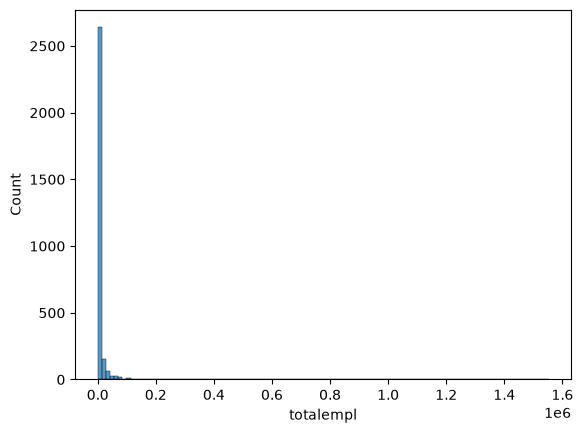

In [201]:
sns.histplot(data[data['year'] == 2018]['totalempl'])
plt.show()

In [202]:
data.loc[data['year'] == 2018, ['totalempl', 'revt']] \
    .sort_values('totalempl', ascending=False) \
    .head(20)

,totalempl,revt
26335,1552543,26405.195118
5050,568895,18066.178096
29898,478746,18068.195133
13062,452676,19807.853646
37030,452050,20489.084511
10213,440250,22151.365742
10898,322334,4316.224764
3020,319532,17911.287986
32811,298734,4589.579073
645,283182,21731.859315


### AI Employment 

just like in employment, we see that taking logs for ai employment ratio yields a almost normal curve which makes further analyses much easier to perform.

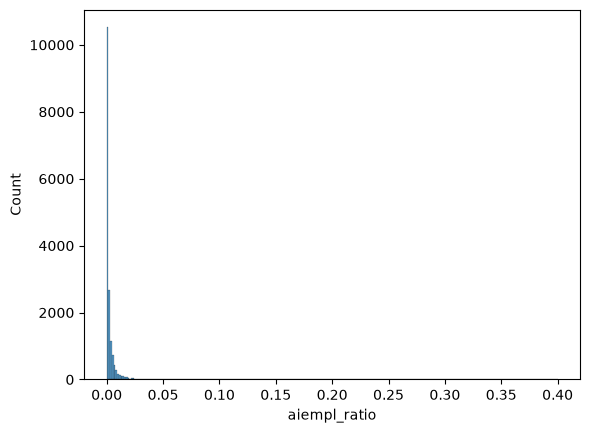

In [203]:
sns.histplot(data[data['aiempl_ratio'] > 0]['aiempl_ratio'])
plt.show()

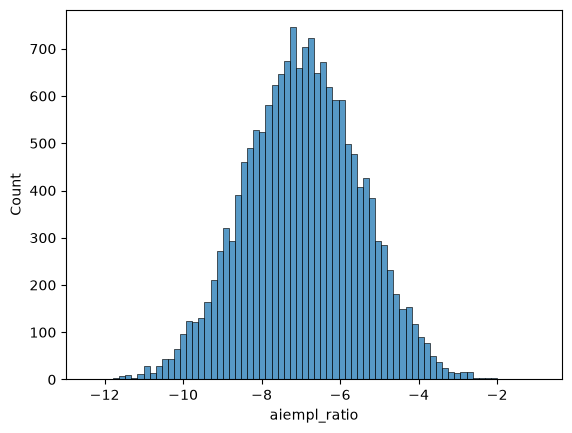

In [204]:
sns.histplot(np.log(data[data['aiempl_ratio'] > 0]['aiempl_ratio']))
plt.show()

# Saving the enriched dataset and subsets 


In [205]:
print(f'max year: {data["year"].max()}')

data_most_recent_year = data[data['year'] == data['year'].max()]


max year: 2018


In [206]:
## 
n_years_threshold = 6

data_years_threshold = data[data["n_years"] >= n_years_threshold]
data_years_threshold.describe().T[['mean', 'std', 'max']].head()

,mean,std,max
gvkey,74601.034192,73245.986986,328795.0000
year,2011.475065,3.859548,2018.0000
aiempl,9.727297,107.151683,6190.0000
totalempl,7828.513391,27050.512869,760596.0000
act,5423.442516,3109.995916,10802.8258


In [207]:
# sns.boxplot(data=data_years_threshold, x = 'year', y = 'aiempl_ratio')
# plt.show()

In [208]:
data.to_pickle(cwd / "data/babina_cleaned_enriched.pkl")
data_most_recent_year.to_pickle(cwd / "data/babina_cleaned_enriched_most_recent_year.pkl")
data_years_threshold.to_pickle(cwd / f"data/babina_cleaned_enriched_years_threshold_{n_years_threshold}_years.pkl")

the following cells looks at the last 20 columns to extract and see the newly created columns (just for an overview)

In [209]:
data.head(5).T.tail(20).index

Index(['productpatent1_fyear_weightvalue', 'processpatent1_fyear',
       'processpatent1_fyear_weightcite', 'processpatent1_fyear_weightvalue',
       'prodmktfluid', 'selffluid', 'aiemp_gt_0', 'aiempl_ratio', 'n_years',
       'first_year', 'last_year', 'market_cap', 'revenue_growth',
       'log_revenue_growth', 'employment_growth', 'roa', 'ni_over_totalempl',
       'log_totalempl', 'log_aiemplratio', 'log_market_cap'],
      dtype='str')

In [210]:
enriched_columns = ['aiemp_gt_0', 'aiempl_ratio', 'n_years', 'first_year', 'last_year',
       'market_cap', 'revenue_growth', 'employment_growth', 'roa',
       'log_totalempl']